# **Loan Approval Prediction**

##### **I chose this dataset because it presents several challenges, it is relatively small with  about 615 rows, and contains many missing values and outliers. I addressed these issues through data preprocessing and was able to achieve an accuracy of 81% and 96% recall, which is a strong result given the limited size of the data."**

### Steps of the Project

1. **Check missing and duplicate values**  
   Check missing values (data has many nulls and it handeled in machine learning pipline ), and removed any duplicate rows.

2. **Univariate analysis**  
   Looked at each column alone to see its values, Handle any wrong data, and check the distribution. Fixed issues when needed.

3. **Bivariate analysis**  
   Checked how each feature is related to the target (loan approval) to find important patterns.

4. **Feature extraction**  
   Made new features from the data to help the model learn better and improve accuracy.

5. **Feature importance**
Checked important features using correlation and ExtraTreesClassifier to find factors that affect loan approval, and removed low-importance ones.

6. **ML Pipelines**  
   Created two pipelines: one for categorical data and one for numeric data. These handled missing values, encoding , scaling and Imbalanced classes.

7. **Model training with cross-validation and pipline**  
   Trained several models using pipelines and cross-validation to avoid data leakage and get fair results.

8. **Choose best model**  
   Picked **SVM** as the best model with **84% accuracy** and **96% recall**, and checked train vs test results to confirm there was no overfitting.

9. **tuning**  
   Did not tune parameters because the dataset was small and past tuning attempts reduced performance.


# 01 · Data Understanding & Cleaning

**Notebook:** 01 of 04  
**Goal:** Load raw data, validate quality, inspect every column, and produce a clean dataset ready for EDA.

### What this notebook covers
- Data loading and schema inspection  
- Duplicate and missing value checks  
- Column-by-column univariate analysis and cleaning decisions  
- Handle skew distributions and outliers by Applying transformation for features
- Outlier check across all numeric features


In [1]:
import plotly.express as px
import pandas as pd
import numpy as np

# for plotly visualizations in SVG format for github
import plotly.io as pio
pio.renderers.default = 'svg'

In [2]:
# import data
df = pd.read_csv('/Users/mohammedmahmood/Desktop/Data projects/Projects/Data science/Supervised /Loan Default Detection Prediction/Data /Loan_Default_Detection_Prediction.csv')
df

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y
...,...,...,...,...,...,...,...,...,...,...,...,...,...
609,LP002978,Female,No,0,Graduate,No,2900,0.0,71.0,360.0,1.0,Rural,Y
610,LP002979,Male,Yes,3+,Graduate,No,4106,0.0,40.0,180.0,1.0,Rural,Y
611,LP002983,Male,Yes,1,Graduate,No,8072,240.0,253.0,360.0,1.0,Urban,Y
612,LP002984,Male,Yes,2,Graduate,No,7583,0.0,187.0,360.0,1.0,Urban,Y


In [3]:
# some info about columns
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            614 non-null    object 
 1   Gender             601 non-null    object 
 2   Married            611 non-null    object 
 3   Dependents         599 non-null    object 
 4   Education          614 non-null    object 
 5   Self_Employed      582 non-null    object 
 6   ApplicantIncome    614 non-null    int64  
 7   CoapplicantIncome  614 non-null    float64
 8   LoanAmount         592 non-null    float64
 9   Loan_Amount_Term   600 non-null    float64
 10  Credit_History     564 non-null    float64
 11  Property_Area      614 non-null    object 
 12  Loan_Status        614 non-null    object 
dtypes: float64(4), int64(1), object(8)
memory usage: 62.5+ KB


In [4]:
df.describe()

,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History
count,614.000000,614.000000,592.000000,600.00000,564.000000
mean,5403.459283,1621.245798,146.412162,342.00000,0.842199
std,6109.041673,2926.248369,85.587325,65.12041,0.364878
min,150.000000,0.000000,9.000000,12.00000,0.000000
25%,2877.500000,0.000000,100.000000,360.00000,1.000000
50%,3812.500000,1188.500000,128.000000,360.00000,1.000000
75%,5795.000000,2297.250000,168.000000,360.00000,1.000000
max,81000.000000,41667.000000,700.000000,480.00000,1.000000


# duplication rows

In [5]:
df.duplicated().sum()

0

# Null Values

In [6]:
df.isna().mean() * 100

Loan_ID              0.000000
Gender               2.117264
Married              0.488599
Dependents           2.442997
Education            0.000000
Self_Employed        5.211726
ApplicantIncome      0.000000
CoapplicantIncome    0.000000
LoanAmount           3.583062
Loan_Amount_Term     2.280130
Credit_History       8.143322
Property_Area        0.000000
Loan_Status          0.000000
dtype: float64

### **I cannot drop the missing values because the dataset has a very small number of rows. Instead, I will impute the missing values within the ML preprocessing pipeline, This ensures proper data handling and prevents data leakage.**

In [7]:
# Unnecessary column in preidction and Analysis
df.drop("Loan_ID" , axis = 1 , inplace=True )
df.reset_index(drop=True, inplace=True)

In [8]:
df.columns

Index(['Gender', 'Married', 'Dependents', 'Education', 'Self_Employed',
       'ApplicantIncome', 'CoapplicantIncome', 'LoanAmount',
       'Loan_Amount_Term', 'Credit_History', 'Property_Area', 'Loan_Status'],
      dtype='object')

# Univariate analysis
### In this step I will go through each column individually to identify and address any issues, and do EDA to gain a deeper understanding of the features.

## **1. Gender**

In [9]:
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

In [10]:
df.Gender.unique()

array(['Male', 'Female', nan], dtype=object)

In [11]:
df.Gender.value_counts()

Gender
Male      489
Female    112
Name: count, dtype: int64

## **2. Married**

In [12]:
df.Married.unique()

array(['No', 'Yes', nan], dtype=object)

In [13]:
df.Married.value_counts()

Married
Yes    398
No     213
Name: count, dtype: int64

## **3. Dependents**

In [14]:
df.Dependents.unique()
## +3, mean greter than 3 Dependents

array(['0', '1', '2', '3+', nan], dtype=object)

In [15]:
df.Dependents.value_counts()

Dependents
0     345
1     102
2     101
3+     51
Name: count, dtype: int64

In [16]:
df.Dependents.info()

<class 'pandas.core.series.Series'>
RangeIndex: 614 entries, 0 to 613
Series name: Dependents
Non-Null Count  Dtype 
--------------  ----- 
599 non-null    object
dtypes: object(1)
memory usage: 4.9+ KB


## **4. Education**

In [17]:
df.Education.unique() 

array(['Graduate', 'Not Graduate'], dtype=object)

## **5. Self_Employed**

In [18]:
df.Self_Employed.unique()

array(['No', 'Yes', nan], dtype=object)

In [19]:
df.Self_Employed.value_counts()

Self_Employed
No     500
Yes     82
Name: count, dtype: int64

## **6. ApplicantIncome**

In [20]:
df.ApplicantIncome.describe()

count      614.000000
mean      5403.459283
std       6109.041673
min        150.000000
25%       2877.500000
50%       3812.500000
75%       5795.000000
max      81000.000000
Name: ApplicantIncome, dtype: float64

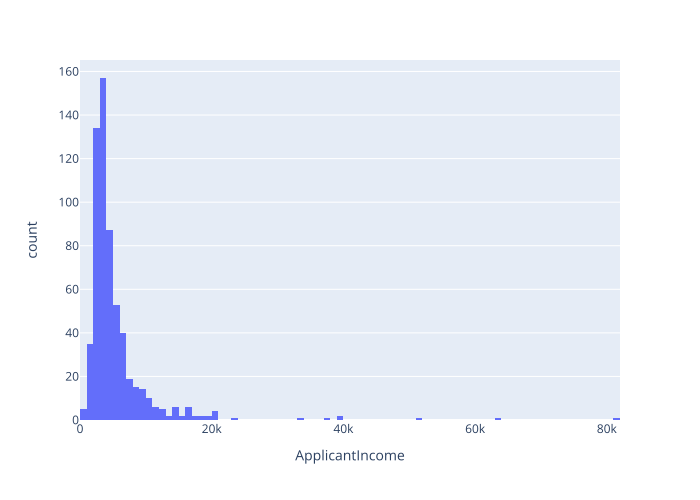

In [21]:
fig = px.histogram(df, x= "ApplicantIncome")

fig.show()

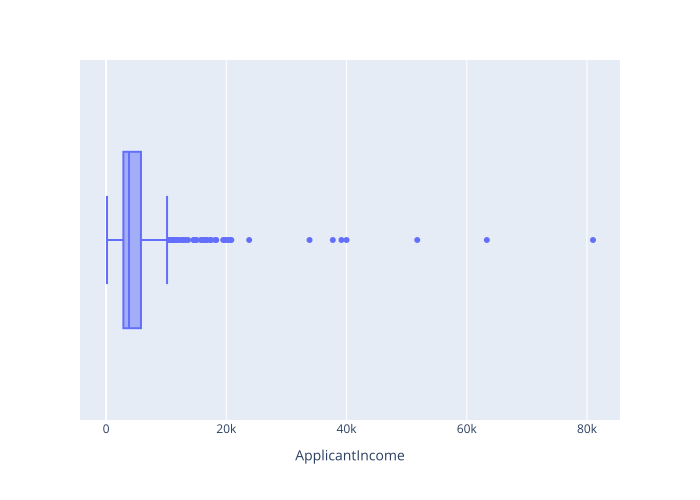

In [22]:
fig = px.box(df, x= "ApplicantIncome")

fig.show()

### **Taking the log of the column helps handle skewness and outliers**

The distribution of  features is right-skewed and contains outliers.  
We will apply appropriate transformations to improve distribution and less number of outliers.

In [23]:
# log transform for ApplicantIncome
df["log_ApplicantIncome"] = np.log(df["ApplicantIncome"])

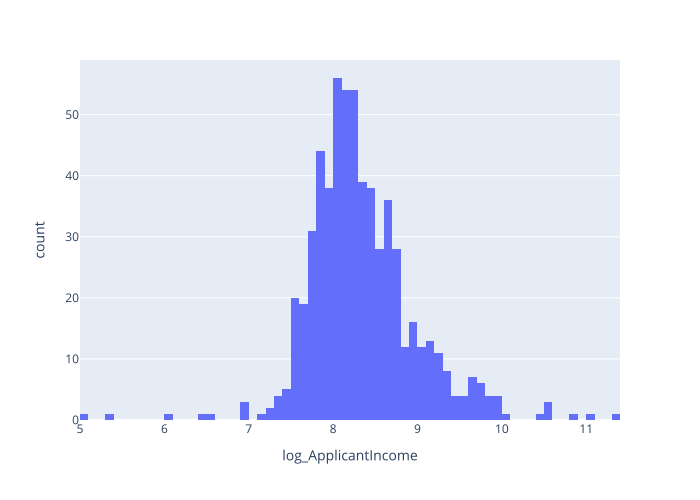

In [24]:
fig = px.histogram(df, x= "log_ApplicantIncome")

fig.show()

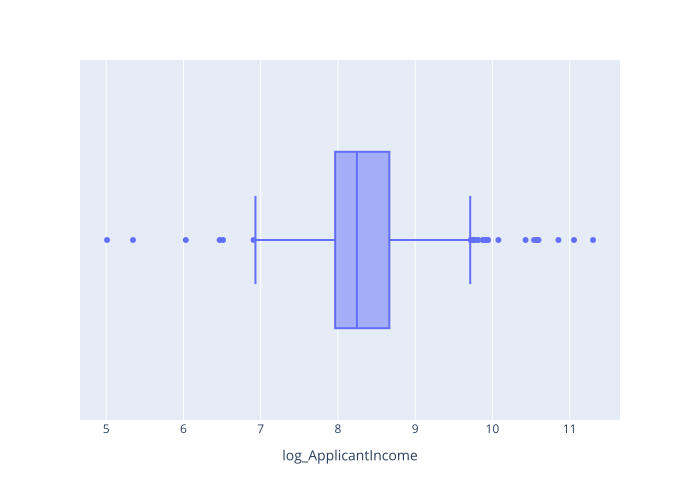

In [25]:
fig = px.box(df, x= "log_ApplicantIncome")

fig.show()

#### **As we saw the log transformation handled skewness and outliers**

## **7. LoanAmount**

In [26]:
df.LoanAmount.describe()

count    592.000000
mean     146.412162
std       85.587325
min        9.000000
25%      100.000000
50%      128.000000
75%      168.000000
max      700.000000
Name: LoanAmount, dtype: float64

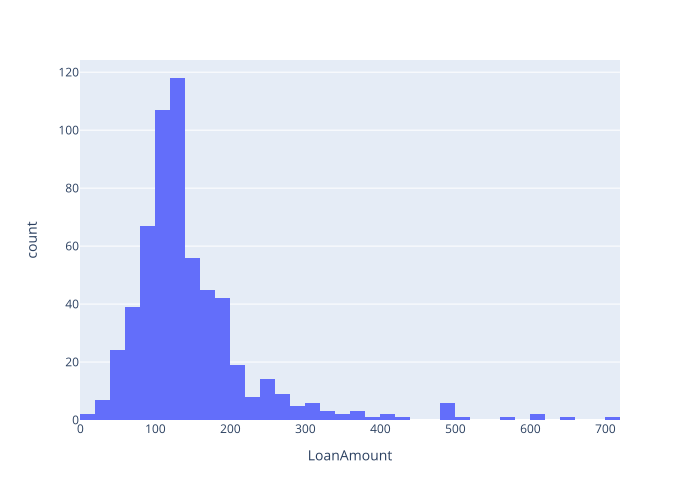

In [27]:
fig = px.histogram(df, x= "LoanAmount")
fig.show()

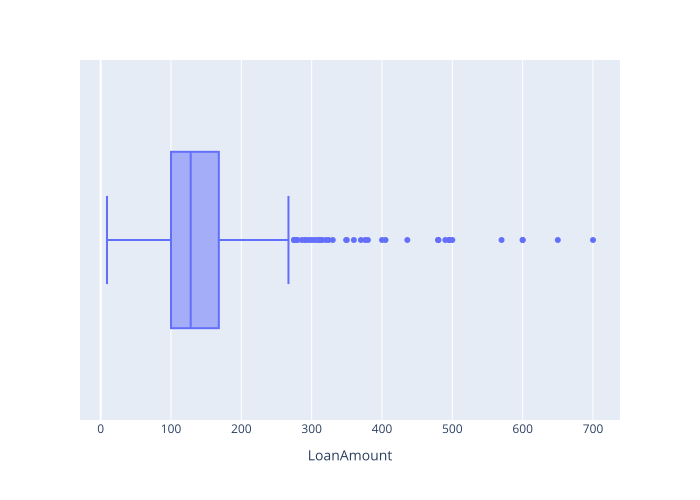

In [28]:
fig= px.box(df, x= "LoanAmount")

fig.show()

### **will apply transformation to handle skwe and outliers**

In [29]:
df["log_LoanAmount"] = np.log(df["LoanAmount"])

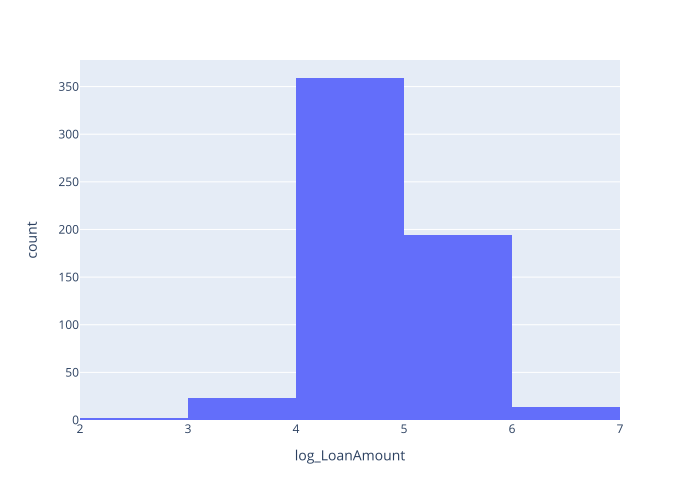

In [30]:
fig = px.histogram(df, x= "log_LoanAmount")

fig.show()

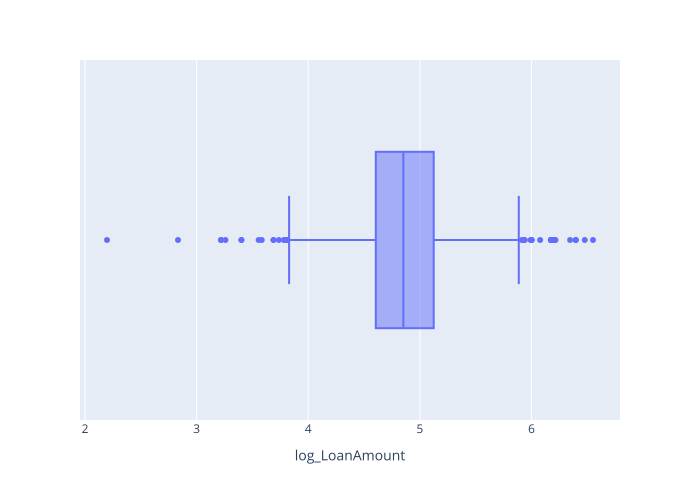

In [31]:
fig = px.box(df, x= "log_LoanAmount")

fig.show()

In [32]:
df.columns

Index(['Gender', 'Married', 'Dependents', 'Education', 'Self_Employed',
       'ApplicantIncome', 'CoapplicantIncome', 'LoanAmount',
       'Loan_Amount_Term', 'Credit_History', 'Property_Area', 'Loan_Status',
       'log_ApplicantIncome', 'log_LoanAmount'],
      dtype='object')

## **8. Loan_Amount_Term**

In [33]:
df.Loan_Amount_Term.describe()

count    600.00000
mean     342.00000
std       65.12041
min       12.00000
25%      360.00000
50%      360.00000
75%      360.00000
max      480.00000
Name: Loan_Amount_Term, dtype: float64

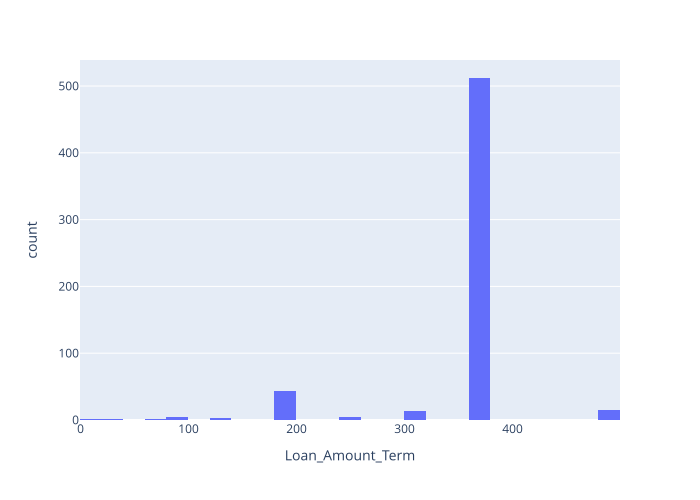

In [34]:
fig = px.histogram(df, x= "Loan_Amount_Term" )

fig.show()

## **9. Credit_History**

In [35]:
df.Credit_History.unique()

array([ 1.,  0., nan])

In [36]:
df.Credit_History.value_counts()

Credit_History
1.0    475
0.0     89
Name: count, dtype: int64

## **10. Property_Area**

In [37]:
df.Property_Area.unique()

array(['Urban', 'Rural', 'Semiurban'], dtype=object)

In [38]:
df.Property_Area.value_counts()

Property_Area
Semiurban    233
Urban        202
Rural        179
Name: count, dtype: int64

## **11. Loan_Status**

In [39]:
df["Loan_Status"]. value_counts()

Loan_Status
Y    422
N    192
Name: count, dtype: int64

#### **The target is imbalanced,  will handle it in Ml pipelin**

In [40]:
# Map Target
# df["Loan_Status"] = df["Loan_Status"].map({"N" : 0, "Y": 1})

# Check Outliers

In [41]:
from datasist.structdata import detect_outliers


DF = df.select_dtypes(include="number")

for col in DF.columns:
    outliers = detect_outliers(df, 0, [col])
    print(f"{col}: {len(outliers)} outliers")


ApplicantIncome: 50 outliers
CoapplicantIncome: 18 outliers
LoanAmount: 0 outliers
Loan_Amount_Term: 0 outliers
Credit_History: 0 outliers
log_ApplicantIncome: 27 outliers
log_LoanAmount: 0 outliers


In [42]:
df.drop_duplicates(inplace=True)
df.reset_index(drop=True, inplace=True)

### **The number of outliers has decreased significantly after applying transformations on the skewed columns.**

In [43]:
# ── Save cleaned data for notebook  ────────────────────────────────────────
import os
os.makedirs("data", exist_ok=True)
df.to_csv("data/01_cleaned.csv", index=False)
print(f"Saved → data/01_cleaned.csv  |  shape: {df.shape}")

Saved → data/01_cleaned.csv  |  shape: (614, 14)
